In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import f90nml

In [ ]:
def readEnergies(dir, energyFilename):
  subdirs = [d for d in os.listdir(dir) if os.path.isdir(os.path.join(dir, d))]
  energiesColnames = ["state", "E"]
  energiesList = []
  for subdir in subdirs:
    pathToNml = os.path.join(dir, subdir, 'OutputData')
    with open(os.path.join(pathToNml, 'quantum_dot.nml')) as nmlFile:
      nml = f90nml.read(nmlFile)
      param = nml['external_parameters']['d_image']
      energies = pd.read_csv(os.path.join(pathToNml, energyFilename), skiprows=1, comment="#", names=energiesColnames, sep="\s+")
      energies['d_image'] = param
      energiesList.append(energies)

  energiesDf = pd.concat(energiesList, ignore_index=True)
  return energiesDf


def readExpectations(dir, expectationsFilename):
  subdirs = [d for d in os.listdir(dir) if os.path.isdir(os.path.join(dir, d))]
  expectationColnames = ["state", "x", "S_x", "S_y", "S_z",    "d_xy_up",   "d_xy_down",   "d_xz_up",   "d_xz_down",   "d_yz_up",   "d_yz_down",   "parity",   "S_z^L",  "S_z^R",   "V_image",  "V_confinement",   "V_Coulomb",   "r_12",   "H_0"]
  expectationsList = []
  for subdir in subdirs:
    pathToNml = os.path.join(dir, subdir, 'OutputData')
    with open(os.path.join(pathToNml, 'quantum_dot.nml')) as nmlFile:
      nml = f90nml.read(nmlFile)
      param = nml['external_parameters']['d_image']
      energies = pd.read_csv(os.path.join(pathToNml, expectationsFilename), skiprows=1, comment="#", names=expectationColnames, sep="\s+")
      energies['d_image'] = param
      expectationsList.append(energies)

  energiesDf = pd.concat(expectationsList, ignore_index=True)
  return energiesDf


<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3881553/289690438.py:10: SyntaxWarning: invalid escape sequence '\s'
  energies = pd.read_csv(os.path.join(pathToNml, energyFilename), skiprows=1, comment="#", names=energiesColnames, sep="\s+")


In [8]:
omega = 18
energies1eNoImage = readEnergies(f"/home/czarnecki/SCRATCH/STO_QD/STO_QD_d_image_omega_{omega}_1e", "Energies1_no_image.dat")
energies1eWithImage = readEnergies(f"/home/czarnecki/SCRATCH/STO_QD/STO_QD_d_image_omega_{omega}_1e", "Energies1.dat")
energies2eNoImage = readEnergies(f"/home/czarnecki/SCRATCH/STO_QD/STO_QD_d_image_omega_{omega}_2e", "Energies2_no_image.dat")
energies2eWithImage = readEnergies(f"/home/czarnecki/SCRATCH/STO_QD/STO_QD_d_image_omega_{omega}_2e", "Energies2.dat")

In [9]:
baseStateEnergies1eNoImage = energies1eNoImage[energies1eNoImage['state'] == 1]
baseStateEnergies1eNoImage.sort_values('d_image', inplace=True)
baseStateEnergies1eWithImage = energies1eWithImage[energies1eWithImage['state'] == 1]
baseStateEnergies1eWithImage.sort_values('d_image', inplace=True)
baseStateEnergies2eNoImage = energies2eNoImage[energies2eNoImage['state'] == 1]
baseStateEnergies2eNoImage.sort_values('d_image', inplace=True)
baseStateEnergies2eWithImage = energies2eWithImage[energies2eWithImage['state'] == 1]
baseStateEnergies2eWithImage.sort_values('d_image', inplace=True)

/tmp/ipykernel_3881553/2232852858.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  baseStateEnergies1eNoImage.sort_values('d_image', inplace=True)
/tmp/ipykernel_3881553/2232852858.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  baseStateEnergies1eWithImage.sort_values('d_image', inplace=True)
/tmp/ipykernel_3881553/2232852858.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  baseStateEnergies2eNoImage.sort_values('d_image', i

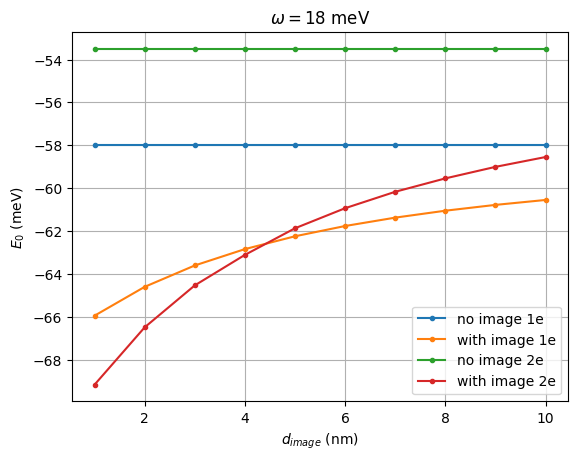

In [10]:
plt.plot(baseStateEnergies1eNoImage['d_image'], 2 * baseStateEnergies1eNoImage['E'], '.-', label = "no image 1e")
plt.plot(baseStateEnergies1eWithImage['d_image'], 2 * baseStateEnergies1eWithImage['E'], '.-', label = "with image 1e")
plt.plot(baseStateEnergies2eNoImage['d_image'], baseStateEnergies2eNoImage['E'], '.-', label = "no image 2e")
plt.plot(baseStateEnergies2eWithImage['d_image'], baseStateEnergies2eWithImage['E'], '.-', label = "with image 2e")

plt.xlabel(r"$d_{image}$ (nm)")
plt.ylabel(r"$E_0$ (meV)")
plt.legend()
plt.title(fr"$\omega = {omega}$ meV")
plt.grid()
plt.show()